In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

# Configure plotting for notebooks
%matplotlib inline
sns.set_theme(style="whitegrid")


In [2]:
import os
import pandas as pd
import numpy as np

file_path = 'data/train.csv'

try:
    # Attempt to load the CSV file
    df = pd.read_csv(file_path)
    print(f"Successfully loaded dataset from {file_path}")
    
except FileNotFoundError:
    print(f"File not found at '{file_path}'. Generating a dummy dataset for testing...")
    
    # Generate a small dummy dataset mimicking CICIDS2017 structure
    np.random.seed(42)
    dummy_data = {
        ' Destination Port': np.random.choice([80, 443, 22, 53, 8080], 100),
        ' Flow Duration': np.random.uniform(10, 100000, 100),
        ' Total Fwd Packets': np.random.randint(1, 50, 100),
        ' Total Backward Packets': np.random.randint(1, 50, 100),
        ' Label': np.random.choice(['BENIGN', 'Anomaly'], 100, p=[0.95, 0.05])
    }
    
    # Create the directory if it doesn't exist
    os.makedirs(os.path.dirname(file_path), exist_ok=True)
    
    # Save to CSV
    df = pd.DataFrame(dummy_data)
    df.to_csv(file_path, index=False)
    print(f"Saved dummy dataset to '{file_path}'")

# Strip leading and trailing whitespace from column names
df.columns = df.columns.str.strip()

# Print the shape of the dataset
print(f"\nDataset shape: {df.shape}")

# Show the first 5 rows
df.head()


File not found at 'data/train.csv'. Generating a dummy dataset for testing...
Saved dummy dataset to 'data/train.csv'

Dataset shape: (100, 5)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Label
0,53,91496.817958,11,29,BENIGN
1,8080,85005.357393,28,49,BENIGN
2,22,44950.572907,25,46,BENIGN
3,8080,9550.057548,23,31,BENIGN
4,8080,37088.117037,31,35,BENIGN


In [4]:
# Randomly sample 100,000 rows to make the dataset manageable
# df = df.sample(n=100000, random_state=42).reset_index(drop=True)
# 

In [7]:
import pandas as pd

# Update this path to wherever you place the downloaded CICIDS2017 CSV file!
file_path = 'combinenew.csv'# Example filename

print("Loading the massive dataset... this might take a minute.")
df = pd.read_csv(file_path)

# Strip leading and trailing whitespace from column names 
df.columns = df.columns.str.strip()

print(f"Original dataset shape: {df.shape}")

# Reduce the dataset down to a usable dimension (e.g., 100,000 rows)
# We use random_state so you get the same random sample every time you run it
df = df.sample(n=100000, random_state=42).reset_index(drop=True)

print(f"Reduced dataset shape: {df.shape}")

# Display the first 5 rows of the reduced dataset
df.head()


Loading the massive dataset... this might take a minute.


C:\Users\Galaxy Book 3pro\AppData\Local\Temp\ipykernel_23068\3446473809.py:7: DtypeWarning: Columns (0:  Destination Port) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


Original dataset shape: (2830744, 79)
Reduced dataset shape: (100000, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,64105,13.0,1.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.000000,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,53,30774.0,1.0,1.0,51.0,67.0,51.0,51.0,51.000000,0.000000,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,59996,1680.0,3.0,0.0,31.0,0.0,31.0,0.0,10.333333,17.897858,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,8083,44.0,1.0,1.0,2.0,6.0,2.0,2.0,2.000000,0.000000,...,24.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PortScan
4,53,668.0,1.0,1.0,51.0,89.0,51.0,51.0,51.000000,0.000000,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [8]:
import numpy as np

print("Cleaning data...")

# 1. Replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2. Drop missing values
df.dropna(inplace=True)

# 3. Convert all columns to numeric where possible
# 'ignore' ensures that text columns (like 'Label') are left alone
df = df.apply(pd.to_numeric, errors='ignore')

# 4. Drop any remaining NaN rows that might have been introduced
df.dropna(inplace=True)

# 5. Print final dataset shape
print(f"Final cleaned dataset shape: {df.shape}")

# Show a summary of the data types to verify the conversion worked
print("\nColumn Data Types Summary:")
print(df.dtypes.value_counts())


Cleaning data...


ValueError: invalid error value specified

In [9]:
import numpy as np
import pandas as pd

print("Cleaning data...")

# 1. Replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 2. Drop missing values
df.dropna(inplace=True)

# 3. Convert columns to numeric (Safe for new pandas versions)
for col in df.columns:
    try:
        df[col] = pd.to_numeric(df[col])
    except (ValueError, TypeError):
        # If it can't be converted (like the text 'Label' column), just skip it
        pass

# 4. Drop any remaining NaN rows that might have been introduced
df.dropna(inplace=True)

# 5. Print final dataset shape
print(f"Final cleaned dataset shape: {df.shape}")

# Show a summary of the data types to verify the conversion worked
print("\nColumn Data Types Summary:")
print(df.dtypes.value_counts())


Cleaning data...
Final cleaned dataset shape: (99888, 79)

Column Data Types Summary:
float64    77
int64       1
str         1
Name: count, dtype: int64


In [10]:
import os
import joblib

# Check for the exact name of the Label column (sometimes it has a leading space)
label_col = 'Label'
if ' Label' in df.columns:
    label_col = ' Label'

# Separate 'Label' column if present
if label_col in df.columns:
    y = df[label_col]
    X = df.drop(columns=[label_col])
    print(f"Separated features (X) from '{label_col}' (y).")
else:
    # If there's no label (e.g., in raw production data), everything is a feature
    X = df.copy()
    y = None
    print("No 'Label' column found. Treating all columns as features.")

# Store feature column names in a list
feature_columns = list(X.columns)

# Create models directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save feature names using joblib
features_path = 'models/features.joblib'
joblib.dump(feature_columns, features_path)
print(f"Saved {len(feature_columns)} feature names to '{features_path}'")

# Print final number of features
print(f"Total Number of features: {X.shape[1]}")


Separated features (X) from 'Label' (y).
Saved 78 feature names to 'models/features.joblib'
Total Number of features: 78


In [11]:
from sklearn.preprocessing import StandardScaler
import joblib

print("Scaling features...")

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler to the data and transform it
# This converts our dataframe X into a scaled numpy array
X_scaled = scaler.fit_transform(X)

# Save the fitted scaler so we can use it later in our Flask API
scaler_path = 'models/scaler.joblib'
joblib.dump(scaler, scaler_path)

print("Features successfully scaled.")
print(f"Scaler saved to '{scaler_path}'")

# Print the shape and the first row to verify
print(f"Shape of scaled data: {X_scaled.shape}")
print(f"First row of scaled data:\n{X_scaled[0][:5]} ...") # previewing just the first 5 values


Scaling features...
Features successfully scaled.
Scaler saved to 'models/scaler.joblib'
Shape of scaled data: (99888, 78)
First row of scaled data:
[ 3.05550335 -0.44029683 -0.01077068 -0.00947008 -0.08639834] ...


In [12]:
from sklearn.ensemble import IsolationForest
import joblib

print("Training Isolation Forest Model...")
print("This may take a moment depending on the size of your dataset...")

# Initialize the Isolation Forest model
# contamination=0.01 assumes ~1% of the network traffic are anomalies/attacks
# n_jobs=-1 tells it to use all your CPU cores to train faster!
model = IsolationForest(contamination=0.01, random_state=42, n_jobs=-1)

# Fit the model on our scaled data
model.fit(X_scaled)

# Save the trained model for the Flask API
model_path = 'models/model.joblib'
joblib.dump(model, model_path)

print("Model successfully trained!")
print(f"Model saved to '{model_path}'")


Training Isolation Forest Model...
This may take a moment depending on the size of your dataset...
Model successfully trained!
Model saved to 'models/model.joblib'


Generating predictions and creating PCA visualization...

Prediction Counts:
Normal     98889
Anomaly      999
Name: count, dtype: int64


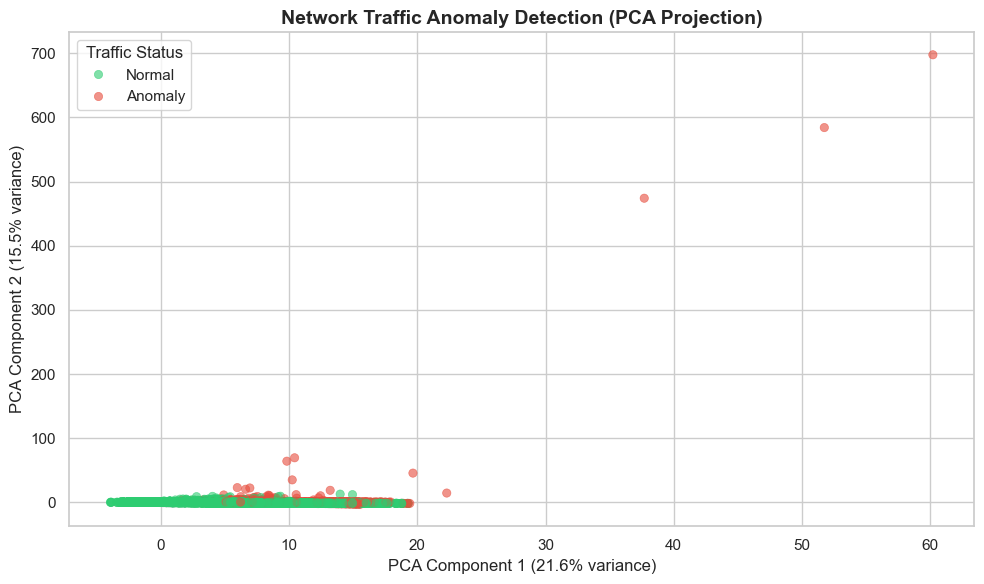

In [13]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("Generating predictions and creating PCA visualization...")

# 1. Get predictions from the model 
# Isolation Forest returns 1 for normal, and -1 for anomalies
predictions = model.predict(X_scaled)

# Convert -1 and 1 to readable text labels for our plot
pred_labels = ['Anomaly' if p == -1 else 'Normal' for p in predictions]

# Print out the anomaly counts
print("\nPrediction Counts:")
print(pd.Series(pred_labels).value_counts())

# 2. Apply PCA to reduce our many features down to 2 dimensions
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# 3. Create a temporary DataFrame just for Seaborn plotting
pca_df = pd.DataFrame({
    'PCA Component 1': X_pca[:, 0],
    'PCA Component 2': X_pca[:, 1],
    'Status': pred_labels
})

# 4. Create the Scatter Plot
plt.figure(figsize=(10, 6))

# Set a custom color palette (Green for normal, Red for anomaly)
custom_palette = {'Normal': '#2ecc71', 'Anomaly': '#e74c3c'}

sns.scatterplot(
    data=pca_df,
    x='PCA Component 1',
    y='PCA Component 2',
    hue='Status',
    palette=custom_palette,
    alpha=0.6,          # Slight transparency to see overlapping points
    edgecolor=None
)

# 5. Add title and labels
plt.title('Network Traffic Anomaly Detection (PCA Projection)', fontsize=14, fontweight='bold')

# The axis labels show how much variance (information) each PCA component captured
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)

plt.legend(title='Traffic Status')
plt.tight_layout()

# Display the plot
plt.show()


In [14]:
import pandas as pd
import numpy as np

# 1. Get hard predictions (1 = Normal, -1 = Anomaly)
predictions = model.predict(X_scaled)
df['Prediction_Label'] = np.where(predictions == 1, 'Normal', 'Anomaly')

# 2. Get raw anomaly scores using decision_function()
# Note: Lower scores (more negative) indicate higher abnormality.
# Higher scores (positive) indicate normal data.
df['Anomaly_Score'] = model.decision_function(X_scaled)

print("Top 5 most severe anomalies:")
# Sort by the lowest score to see the most extreme outliers
display(df[df['Prediction_Label'] == 'Anomaly'].sort_values('Anomaly_Score').head())


Top 5 most severe anomalies:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Prediction_Label,Anomaly_Score
11975,443,103599913.0,336.0,439.0,13641.0,1230735.0,1290.0,0.0,40.598214,131.100084,...,5.439772e+06,7766823.0,73823.0,47800000.0,1.480000e+07,58200000.0,37300000.0,BENIGN,Anomaly,-0.110419
99273,443,71383486.0,402.0,502.0,4972.0,1179961.0,300.0,0.0,12.368159,39.948580,...,1.502093e+06,4256083.0,2131803.0,32500000.0,3.730000e+07,58900000.0,6095206.0,BENIGN,Anomaly,-0.107000
27033,80,93540060.0,3542.0,4706.0,24690.0,10300000.0,329.0,0.0,6.970638,20.506361,...,1.520000e+07,21600000.0,101650.0,35900000.0,3.800000e+07,62800000.0,9031831.0,BENIGN,Anomaly,-0.105940
22636,443,119751512.0,6290.0,6380.0,35609.0,18000000.0,753.0,0.0,5.661208,10.314756,...,2.177931e+06,3153492.0,73433.0,58200000.0,1.476708e+05,58300000.0,58100000.0,BENIGN,Anomaly,-0.102905
64215,443,82452165.0,733.0,1033.0,18752.0,1584745.0,226.0,0.0,25.582538,39.053072,...,1.230000e+07,17900000.0,525226.0,31900000.0,3.750000e+07,58400000.0,5315191.0,BENIGN,Anomaly,-0.102011


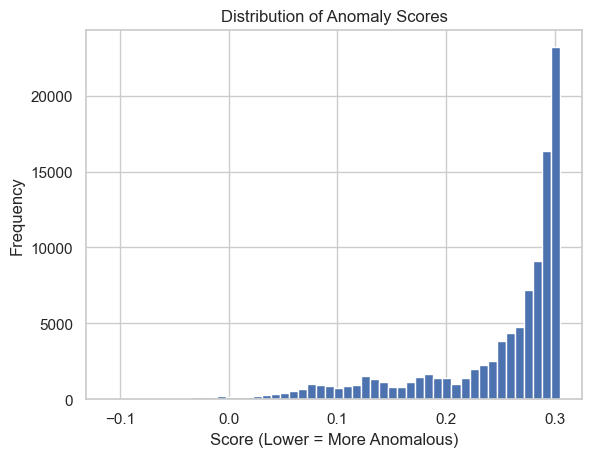

In [15]:
import matplotlib.pyplot as plt

# Plot the distribution of anomaly scores
plt.hist(df['Anomaly_Score'], bins=50)
plt.title("Distribution of Anomaly Scores")
plt.xlabel("Score (Lower = More Anomalous)")
plt.ylabel("Frequency")
plt.show()

# Look for the "elbow" or long tail on the left side of the histogram.
# You can manually set a threshold, e.g., anything below -0.15 is an anomaly:
custom_threshold = -0.15
df['Custom_Label'] = np.where(df['Anomaly_Score'] < custom_threshold, 'Anomaly', 'Normal')


In [17]:
# pip install shap
import shap

# Initialize the SHAP explainer on your trained model
# Note: SHAP can be slow, so we explain a small background sample
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_scaled[:100]) # Example on first 100 rows

# Visualize why the first data point was flagged
shap.initjs()
shap.force_plot(explainer.expected_value[0], shap_values[0][0], X.iloc[0])


c:\Users\Galaxy Book 3pro\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ValueError: visualize() can only display Explanation objects (or arrays of them)!